# Fine-tuning RoBERTa on FOMC hawkish–dovish text
#### Full, LoRA, and QLoRA on Combined-S


The Federal Open Market Committee (FOMC) is the Fed group that sets the federal funds rate. That overnight bank rate shows up in the prices people actually pay: mortgages, car loans, credit cards, and what a savings account yields. When the committee sounds **hawkish**, they are leaning toward tighter policy — higher rates to cool inflation, which makes borrowing more expensive and can slow hiring. When they sound **dovish**, they are leaning toward easier policy — lower rates to support growth, which cheapens a mortgage and can let prices run. Households and markets do not wait for the vote; they read the minutes, press conferences, and speeches for that lean.

[Shah et al. (2023)](https://aclanthology.org/2023.acl-long.368/) turn that reading into a three-way label on FOMC sentences (hawkish / dovish / neutral). We follow their Combined-S recipe. LoRA and QLoRA are the only change to the trainer. Flyte 2 is how the same `workflow.py` runs on this MacBook Pro, on one RTX PRO 6000 Blackwell, or on four on one node.

- Why FOMC language shows up in a mortgage payment
- One pipeline: laptop → 1 GPU → 4 GPUs
- Full vs LoRA vs QLoRA
- 3-seed F1 vs their Table 5


## One pipeline

![](images/flyte_pipeline.png)

*Image Credit: original diagram for this tutorial.*

A training script is enough to fine-tune RoBERTa **once, on one box**. It is the wrong shape the moment you have **two machines**, **CPU work mixed with GPU work**, and a **grid** (two sizes × three methods × three seeds). **Flyte 2 is one `workflow.py`.** Change the command, not the pipeline.

- **One DAG** — CPU `prepare_data`, GPU `train_one` / `grid`, later a CPU stub. No Mac script plus CUDA script.
- **Same deps** — the GPU image is `requirements.txt` on this Mac and on the RTX PRO 6000 Blackwell.
- **Skip / retry** — a finished `metrics.json` is skipped; one failed cell retries, not the whole 18-run grid.
- **Same UI** — Sub actions, Input, Output, Reports on the laptop and on the GPU node.
- **1 GPU/job** — `FLYTE_GPUS=1` and `--parallel jobs` so four cards run four cells. (4 GPUs/model is a Results placeholder — DDP is not wired yet.)

`--local` here (MPS). `flyte run` on one Blackwell or four on one node (CUDA, including QLoRA). SDK notes and the exact commands are in **CLI** at the bottom.


## Task
![](images/hawkish_dovish_task.png)

*Image Credit: original diagram for this tutorial.*

*Idea Credit: [Shah et al. (2023)](https://aclanthology.org/2023.acl-long.368/). Example sentences are illustrative, not quoted from the paper.*


[Shah et al. (2023)](https://aclanthology.org/2023.acl-long.368/) label FOMC minutes, pressers, and speeches as dovish / hawkish / neutral. Combined-S is ~2,480 sentences (1996–2022), seeds `5768`, `78516`, `944601` — random 80/20, not a year cutoff. Table 5 weighted F1: RoBERTa-base **0.698 ± 0.010**, RoBERTa-large **0.711 ± 0.011**. Data: [gtfintechlab/fomc-hawkish-dovish](https://github.com/gtfintechlab/fomc-hawkish-dovish) (CC BY-NC 4.0). Released model: [`gtfintechlab/FOMC-RoBERTa`](https://huggingface.co/gtfintechlab/FOMC-RoBERTa).

Their loop: AdamW, max length 256, 20% val, patience 7, last checkpoint. Combined-S winners: base batch 8 / 1e-5, large batch 16 / 1e-5. We keep that loop; LoRA / QLoRA only change adapters.


## Full fine-tuning vs LoRA vs QLoRA
![](images/full_lora_qlora.png)

*Image Credit: original diagram for this tutorial.*

*Idea Credit: LoRA, [Hu et al., 2021](https://arxiv.org/abs/2106.09685); QLoRA, [Dettmers et al., 2023](https://arxiv.org/abs/2305.14314).*


**Full fine-tuning** updates every weight — the setup in Shah et al. (2023), and our quality target.

**LoRA** ([Hu et al., 2021](https://arxiv.org/abs/2106.09685)) freezes \(W\) and trains \(A \times B\), scaled by \(\alpha / r\). On RoBERTa we target `query`, `key`, `value`, `dense` and fully train the head (`modules_to_save=["classifier"]`).

**QLoRA** ([Dettmers et al., 2023](https://arxiv.org/abs/2305.14314)) keeps those adapters and stores the frozen base in 4-bit (NF4) via [bitsandbytes](https://github.com/bitsandbytes-foundation/bitsandbytes). That path needs **NVIDIA CUDA**, not MPS. This Mac runs base + large, full and LoRA. One or more **RTX PRO 6000 Blackwell (96 GB)** cards run the 2×3, including QLoRA.

Checkpoints: `checkpoints/`. Resume is the default; `FORCE = True` starts over.


## Training and evaluating on Combined-S

Run from `02_fomc_roberta`. Same `workflow.py` as the CLI. The grid resumes from `metrics.json`; `FORCE = True` starts over.

In [9]:
from pathlib import Path
import os

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import flyte
import flyte.report  # required — import flyte does not load this submodule

import config as cfg
from device_utils import describe, detect_device, has_nvidia
from flyte_env import cpu_env, gpu_env, llm_8b_env, ui_env
from load_data import train_val_test
from paper_baselines import paper_table
from run_grid import (
    collect_completed,
    format_per_seed,
    format_results,
    load_runs,
    machine_label,
    style_results_by_machine,
    summarize_runs,
)
from train_run import load_trained, predict_texts
from workflow import grid, main, pipeline, prepare_data, train_one

ROOT = Path.cwd()
assert (ROOT / "workflow.py").exists(), f"Run this notebook from 02_fomc_roberta (cwd={ROOT})"
print("Working directory:", ROOT)
print("Device:", describe())
print("NVIDIA / QLoRA:", has_nvidia())
print("TaskEnvironments:", cpu_env.name, gpu_env.name, ui_env.name)
print("Llama-3.1-8B placeholder (no tasks):", llm_8b_env.name)

# Same objects as workflow.py / flyte_env.py
print("\n--- flyte_env.py (TaskEnvironment) ---\n")
print((ROOT / "flyte_env.py").read_text())
_src = (ROOT / "workflow.py").read_text()
_i = _src.index("@gpu_env.task")
print("--- workflow.py @gpu_env.task train_one ---\n")
print(_src[_i : _i + 700])

# False = in-process (like `flyte run --local`). True = devbox browser UI.
USE_DEVBOX = False
FORCE = False
SMOKE = False
MAX_EPOCHS = 2 if SMOKE else None

if USE_DEVBOX:
    flyte.init_from_config(ROOT / ".flyte/devbox.yaml")
    print("flyte.init_from_config(.flyte/devbox.yaml) — browser at http://localhost:30080/v2")
else:
    flyte.init()
    print("flyte.init() — in-process, same functions as remote. No :30080.")


Working directory: /Users/mgalarnyk/Desktop/Python_Tutorials/NLP/Fine_Tuning/02_fomc_roberta
Device: mps
NVIDIA / QLoRA: False
TaskEnvironments: fomc-roberta-cpu fomc-roberta-gpu fomc-roberta-ui
Llama-3.1-8B placeholder (no tasks): llm-8b-gpu

--- flyte_env.py (TaskEnvironment) ---

"""Flyte 2 task environments: CPU for data, GPU for the paper-loop train."""

from __future__ import annotations

import os
import shutil

import flyte

# Flyte resource GPU count is NVIDIA. On this MacBook Pro, request 0 so
# --local still runs; PyTorch uses MPS inside the task. Devbox: `flyte start
# devbox` here (no --gpu — Apple Silicon unsupported). On a remote NVIDIA
# RTX PRO 6000 Blackwell (96 GB): `flyte start devbox --gpu`, default 1 GPU.
# Set FLYTE_GPUS=4 only when a task should own four cards (DDP). For
# 1 GPU/job on a 4-GPU node keep FLYTE_GPUS=1 and pass --parallel jobs.
_HAS_NVIDIA = shutil.which("nvidia-smi") is not None


def requested_gpus() -> int:
    if not _HAS_NVIDIA:
        return

### Step 1: Load the paper's splits

Files come from [gtfintechlab/fomc-hawkish-dovish](https://github.com/gtfintechlab/fomc-hawkish-dovish) (CC BY-NC 4.0). They are **not** stored in git. Default split is Combined-S: `lab-manual-split-combine`.

In [11]:
# Each paper seed has its own train/test xlsx. Peek at seed 5768; the grid trains all three.
train, val, test = train_val_test(seed=cfg.PAPER_SEEDS[0], split=cfg.DEFAULT_SPLIT)
print(f"seed={cfg.PAPER_SEEDS[0]}  train={len(train):,}  val={len(val):,}  test={len(test):,}")
print("\nTrain label counts:")
print(train["label_name"].value_counts())
train.head(3)

seed=5768  train=1,588  val=396  test=496

Train label counts:
label_name
neutral    784
dovish     416
hawkish    388
Name: count, dtype: int64


,text,label,label_name
0,"However, economic activity continued to be dep...",2,neutral
1,To abstract from the potential effects of cycl...,2,neutral
2,"Thus, avoiding a further substantial fall in i...",0,dovish


### Step 2: Confirm labels and the published Table 5 numbers

| Id | Name | Policy stance |
|----|------|----------------|
| 0 | dovish | Easing / more accommodative |
| 1 | hawkish | Tightening / less accommodative |
| 2 | neutral | No clear stance |

Paper metric is **weighted F1**. Combined-S: RoBERTa-base **0.698**, RoBERTa-large **0.711**. Combined (no sentence split): large **0.717** — that is their headline number.

In [13]:
paper_table(cfg.DEFAULT_SPLIT)

,who,model,method,split,weighted_f1,weighted_f1_std
0,"Shah et al. (full FT, 3-seed mean)",roberta-base,full,lab-manual-split-combine,0.6981,0.0097
1,"Shah et al. (full FT, 3-seed mean)",roberta-large,full,lab-manual-split-combine,0.7113,0.0106


### Two ways to use four GPUs

The CUDA grid is six cells: RoBERTa-base and RoBERTa-large, each with full, LoRA, and QLoRA (three seeds each — 18 runs). On **one** RTX PRO 6000 Blackwell those jobs run one after another.

On **four** cards on one node, Flyte is how you pick the layout — same `workflow.py`, different invoke:

1. **4 GPUs per model** — one cell (for example RoBERTa-large full) uses DistributedDataParallel across the node. That is for **one job’s** time. F1 can move a little unless the per-GPU batch stays equivalent to the paper. Still a placeholder; `paper_loop.py` is single-device.
2. **1 GPU per job** — `FLYTE_GPUS=1 flyte run workflow.py grid --parallel jobs`. Flyte schedules unfinished cells in parallel (one GPU each). Each run is still single-device, so F1 should match the 1-GPU row. The number that should drop is **grid wall-clock**: the 18 runs overlap instead of queueing. Do not set `FLYTE_GPUS=4` for this layout — that would make every cell request all four cards.

Both layouts keep all six method cells in the Results table. If a card drops mid-grid, Flyte resumes that cell rather than the whole 2×3; the UI shows which of the 18 runs actually failed. QLoRA stays CUDA-only. This Mac still runs the four MPS cells (base/large × full/LoRA).


### Step 3: Train the comparison grid

| Method | What trains | Typical machine |
|--------|-------------|-----------------|
| Full | All encoder + classifier weights | MacBook Pro (M4 Max, 128 GB, MPS) |
| LoRA | Adapters on `query`, `key`, `value`, `dense` + classifier | MacBook Pro (M4 Max, 128 GB, MPS) |
| QLoRA | LoRA + 4-bit frozen base | RTX PRO 6000 Blackwell, 96 GB (CUDA) |

Same `pipeline` / `grid` as `workflow.py`. `flyte.run(...)` after `flyte.init()` is in-process (this Mac, MPS). After `flyte.init_from_config(.flyte/devbox.yaml)` it is the browser UI — same functions. Finished `metrics.json` is skipped unless `FORCE = True`.


In [ ]:
# Same functions as `flyte run workflow.py pipeline` / `grid`.
# USE_DEVBOX from the import cell: False = in-process; True = http://localhost:30080/v2
r = flyte.run(
    pipeline,
    model_key="roberta-base",
    method="lora",
    seed=cfg.DEFAULT_SEED,
    max_epochs=MAX_EPOCHS,
    force=FORCE,
)
print(r.name)
print(getattr(r, "url", ""))
r.wait()
print(r.outputs)


## Results

Weighted F1, mean ± std over seeds `5768`, `78516`, `944601` on Combined-S, as in Table 5 of [Shah et al. (2023)](https://aclanthology.org/2023.acl-long.368/). Mac times are typical lid-open runs.

**Time** on this Mac and on **1 GPU** / **4 GPUs/model** is typical wall-clock **per cell**. Time on **1 GPU/job** is **full-grid** wall-clock (6 methods × 3 seeds = 18 runs). CUDA F1 and times are placeholders until those runs. vs paper uses their full-FT Table 5 number as the target. **1 GPU/job** F1 should match **1 GPU**; **4 GPUs/model** F1 can shift with effective batch.

Rows are colored by machine.

<span style="display:inline-block;margin:0 10px 6px 0;padding:2px 8px;border-radius:999px;background:#eef0f3;font-size:0.82em">Shah et al. · RTX A6000</span>
<span style="display:inline-block;margin:0 10px 6px 0;padding:2px 8px;border-radius:999px;background:#dbeafe;font-size:0.82em">This Mac · M4 Max, MPS</span>
<span style="display:inline-block;margin:0 10px 6px 0;padding:2px 8px;border-radius:999px;background:#fef3c7;font-size:0.82em">1× RTX PRO 6000 Blackwell</span>
<span style="display:inline-block;margin:0 10px 6px 0;padding:2px 8px;border-radius:999px;background:#ede9fe;font-size:0.82em">4 GPUs/model</span>
<span style="display:inline-block;margin:0 10px 6px 0;padding:2px 8px;border-radius:999px;background:#fde8e6;font-size:0.82em">1 GPU/job</span>

<table>
<thead>
<tr>
<th>Who</th><th>Model</th><th>Method</th><th>Weighted F1</th><th>vs paper</th><th>Epochs</th><th>Time</th><th>Trainable</th><th>Machine</th>
</tr>
</thead>
<tbody>
<tr style="background:#eef0f3"><td>Shah et al.</td><td>RoBERTa-base</td><td>full</td><td><b>0.698 ± 0.010</b></td><td>—</td><td>—</td><td>—</td><td>100%</td><td>RTX A6000</td></tr>
<tr style="background:#eef0f3"><td>Shah et al.</td><td>RoBERTa-large</td><td>full</td><td><b>0.711 ± 0.011</b></td><td>—</td><td>—</td><td>—</td><td>100%</td><td>RTX A6000</td></tr>
<tr style="background:#dbeafe"><td>Ours</td><td>RoBERTa-base</td><td>full</td><td><b>0.697 ± 0.018</b></td><td>−0.001</td><td>11</td><td>~8 min</td><td>100%</td><td>MacBook Pro M4 Max, 128 GB, MPS</td></tr>
<tr style="background:#dbeafe"><td>Ours</td><td>RoBERTa-base</td><td>LoRA</td><td><b>0.685 ± 0.018</b></td><td>−0.013</td><td>28</td><td>~13 min</td><td>2.5%</td><td>MacBook Pro M4 Max, 128 GB, MPS</td></tr>
<tr style="background:#dbeafe"><td>Ours</td><td>RoBERTa-large</td><td>full</td><td><b>0.713 ± 0.016</b></td><td>+0.001</td><td>14</td><td>~25 min</td><td>100%</td><td>MacBook Pro M4 Max, 128 GB, MPS</td></tr>
<tr style="background:#dbeafe"><td>Ours</td><td>RoBERTa-large</td><td>LoRA</td><td><b>0.726 ± 0.016</b></td><td>+0.015</td><td>24</td><td>~25 min</td><td>2.2%</td><td>MacBook Pro M4 Max, 128 GB, MPS</td></tr>
<tr style="background:#fef3c7"><td>Ours</td><td>RoBERTa-base</td><td>full</td><td>—</td><td>—</td><td>—</td><td>—</td><td>100%</td><td>1× RTX PRO 6000 Blackwell, 96 GB, CUDA</td></tr>
<tr style="background:#fef3c7"><td>Ours</td><td>RoBERTa-base</td><td>LoRA</td><td>—</td><td>—</td><td>—</td><td>—</td><td>2.5%</td><td>1× RTX PRO 6000 Blackwell, 96 GB, CUDA</td></tr>
<tr style="background:#fef3c7"><td>Ours</td><td>RoBERTa-base</td><td>QLoRA</td><td>—</td><td>—</td><td>—</td><td>—</td><td>2.5%</td><td>1× RTX PRO 6000 Blackwell, 96 GB, CUDA</td></tr>
<tr style="background:#fef3c7"><td>Ours</td><td>RoBERTa-large</td><td>full</td><td>—</td><td>—</td><td>—</td><td>—</td><td>100%</td><td>1× RTX PRO 6000 Blackwell, 96 GB, CUDA</td></tr>
<tr style="background:#fef3c7"><td>Ours</td><td>RoBERTa-large</td><td>LoRA</td><td>—</td><td>—</td><td>—</td><td>—</td><td>2.2%</td><td>1× RTX PRO 6000 Blackwell, 96 GB, CUDA</td></tr>
<tr style="background:#fef3c7"><td>Ours</td><td>RoBERTa-large</td><td>QLoRA</td><td>—</td><td>—</td><td>—</td><td>—</td><td>2.2%</td><td>1× RTX PRO 6000 Blackwell, 96 GB, CUDA</td></tr>
<tr style="background:#ede9fe"><td>Ours</td><td>RoBERTa-base</td><td>full</td><td>—</td><td>—</td><td>—</td><td>—</td><td>100%</td><td>4× RTX PRO 6000 Blackwell, 4 GPUs/model</td></tr>
<tr style="background:#ede9fe"><td>Ours</td><td>RoBERTa-base</td><td>LoRA</td><td>—</td><td>—</td><td>—</td><td>—</td><td>2.5%</td><td>4× RTX PRO 6000 Blackwell, 4 GPUs/model</td></tr>
<tr style="background:#ede9fe"><td>Ours</td><td>RoBERTa-base</td><td>QLoRA</td><td>—</td><td>—</td><td>—</td><td>—</td><td>2.5%</td><td>4× RTX PRO 6000 Blackwell, 4 GPUs/model</td></tr>
<tr style="background:#ede9fe"><td>Ours</td><td>RoBERTa-large</td><td>full</td><td>—</td><td>—</td><td>—</td><td>—</td><td>100%</td><td>4× RTX PRO 6000 Blackwell, 4 GPUs/model</td></tr>
<tr style="background:#ede9fe"><td>Ours</td><td>RoBERTa-large</td><td>LoRA</td><td>—</td><td>—</td><td>—</td><td>—</td><td>2.2%</td><td>4× RTX PRO 6000 Blackwell, 4 GPUs/model</td></tr>
<tr style="background:#ede9fe"><td>Ours</td><td>RoBERTa-large</td><td>QLoRA</td><td>—</td><td>—</td><td>—</td><td>—</td><td>2.2%</td><td>4× RTX PRO 6000 Blackwell, 4 GPUs/model</td></tr>
<tr style="background:#fde8e6"><td>Ours</td><td>RoBERTa-base</td><td>full</td><td>—</td><td>—</td><td>—</td><td>—</td><td>100%</td><td>4× RTX PRO 6000 Blackwell, 1 GPU/job</td></tr>
<tr style="background:#fde8e6"><td>Ours</td><td>RoBERTa-base</td><td>LoRA</td><td>—</td><td>—</td><td>—</td><td>—</td><td>2.5%</td><td>4× RTX PRO 6000 Blackwell, 1 GPU/job</td></tr>
<tr style="background:#fde8e6"><td>Ours</td><td>RoBERTa-base</td><td>QLoRA</td><td>—</td><td>—</td><td>—</td><td>—</td><td>2.5%</td><td>4× RTX PRO 6000 Blackwell, 1 GPU/job</td></tr>
<tr style="background:#fde8e6"><td>Ours</td><td>RoBERTa-large</td><td>full</td><td>—</td><td>—</td><td>—</td><td>—</td><td>100%</td><td>4× RTX PRO 6000 Blackwell, 1 GPU/job</td></tr>
<tr style="background:#fde8e6"><td>Ours</td><td>RoBERTa-large</td><td>LoRA</td><td>—</td><td>—</td><td>—</td><td>—</td><td>2.2%</td><td>4× RTX PRO 6000 Blackwell, 1 GPU/job</td></tr>
<tr style="background:#fde8e6"><td>Ours</td><td>RoBERTa-large</td><td>QLoRA</td><td>—</td><td>—</td><td>—</td><td>—</td><td>2.2%</td><td>4× RTX PRO 6000 Blackwell, 1 GPU/job</td></tr>
</tbody>
</table>

Per seed (ours, Mac, test weighted F1): base full 0.680 / 0.695 / 0.716; base LoRA 0.664 / 0.694 / 0.697; large full 0.695 / 0.726 / 0.717; large LoRA 0.715 / 0.719 / 0.745.


In [18]:
# Finished paper-loop checkpoints only (ignores older Hugging Face Trainer runs).
runs = collect_completed()
summary = summarize_runs(runs)

print("3-seed mean ± std (ours vs Shah et al.). Rows colored by machine.")
display(style_results_by_machine(format_results(summary)))

if runs.empty:
    print("\nNo finished paper-loop runs yet. Run the grid cell, or re-run this cell as checkpoints finish.")
else:
    print("\nPer-seed runs")
    per = format_per_seed(runs)
    display(style_results_by_machine(per) if "machine" in per.columns else per)


3-seed mean ± std (ours vs Shah et al.). Rows colored by machine.

Per-seed runs
3-seed mean ± std (ours vs Shah et al.). Rows colored by machine.

Per-seed runs


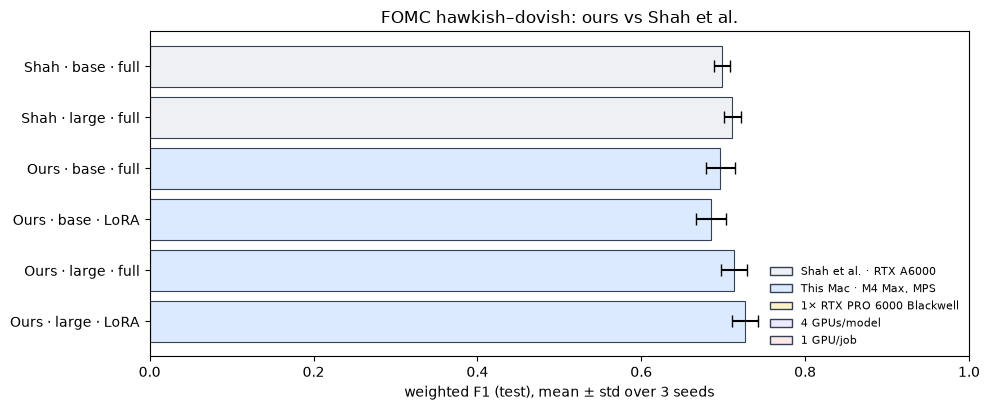

In [19]:
from report_helpers import machine_row_color

plot_df = summary.dropna(subset=["weighted_f1"]).copy()
who = plot_df["who"].astype(str)
plot_df["who_short"] = np.where(who.str.startswith("Shah"), "Shah", "Ours")
plot_df["model_short"] = plot_df["model"].astype(str).str.replace("roberta-", "", regex=False)
plot_df["method_short"] = plot_df["method"].astype(str).str.replace("lora", "LoRA", regex=False)
plot_df["label"] = plot_df["who_short"] + " · " + plot_df["model_short"] + " · " + plot_df["method_short"]
plot_df["machine"] = plot_df["machine"] if "machine" in plot_df.columns else who.map(
    lambda w: "RTX A6000" if str(w).startswith("Shah") else "MacBook Pro M4 Max, 128 GB, MPS"
)
# Same order as the Results table: Shah first, then ours (base before large, full before LoRA).
plot_df["_ord"] = (
    plot_df["who_short"].map({"Shah": 0, "Ours": 1})
    + plot_df["model_short"].map({"base": 0, "large": 1}).fillna(2)
    + plot_df["method"].map({"full": 0, "lora": 1, "qlora": 2}).fillna(3)
)
plot_df = plot_df.sort_values("_ord")
colors = [machine_row_color(str(m)) for m in plot_df["machine"]]
std = plot_df["weighted_f1_std"].fillna(0) if "weighted_f1_std" in plot_df else 0
y = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(y, plot_df["weighted_f1"], xerr=std, capsize=4, color=colors, edgecolor="#344054", linewidth=0.8)
ax.set_yticks(y, plot_df["label"])
ax.invert_yaxis()
ax.set_xlabel("weighted F1 (test), mean ± std over 3 seeds")
ax.set_title("FOMC hawkish–dovish: ours vs Shah et al.")
ax.set_xlim(0, 1)
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, facecolor="#eef0f3", edgecolor="#344054", label="Shah et al. · RTX A6000"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#dbeafe", edgecolor="#344054", label="This Mac · M4 Max, MPS"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#fef3c7", edgecolor="#344054", label="1× RTX PRO 6000 Blackwell"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#ede9fe", edgecolor="#344054", label="4 GPUs/model"),
        plt.Rectangle((0, 0), 1, 1, facecolor="#fde8e6", edgecolor="#344054", label="1 GPU/job"),
    ],
    loc="lower right",
    frameon=False,
    fontsize=8,
)
fig.tight_layout()
fig


### Step 4: Load a checkpoint and classify new sentences

The next cell loads the **best finished run by test weighted F1** and prints **model, method, seed, and F1** before classifying. Override `RUN_DIR` to try another checkpoint. LoRA / QLoRA adapters live in `final/`; `load_trained` attaches them to that run's base (`roberta-base` or `roberta-large`).

In [22]:
runs = load_runs()
ours = runs[(runs["who"] == "ours") & (runs["status"] == "complete")]
if ours.empty:
    raise SystemExit("No finished runs yet — execute the grid cell first.")

best = ours.sort_values("weighted_f1", ascending=False).iloc[0]
RUN_DIR = Path(best["checkpoint_dir"])
method = str(best["method"])
method_disp = {"full": "full FT", "lora": "LoRA", "qlora": "QLoRA"}.get(method, method)
display(
    pd.DataFrame(
        [
            {
                "model": best["model"],
                "method": method_disp,
                "seed": int(best["seed"]),
                "test weighted F1": round(float(best["weighted_f1"]), 4),
                "machine": machine_label(best.get("device"), "ours"),
                "checkpoint": RUN_DIR.name,
            }
        ]
    )
)
model, tokenizer = load_trained(RUN_DIR)

examples = [
    "The Committee judged that a further increase in the target range would be appropriate.",
    "The Committee decided to lower the target range for the federal funds rate.",
    "Incoming data suggested that economic activity was expanding at a moderate pace.",
]
# Argmax class only — softmax scores are not calibrated probabilities.
rows = predict_texts(model, tokenizer, examples)
pd.DataFrame(rows)[["text", "pred_name"]]

model,method,seed,test weighted F1,machine,checkpoint
roberta-large,LoRA,944601,0.7445,"MacBook Pro M4 Max, 128 GB, MPS",roberta-large__lora__lab-manual-split-combine__seed944601__paper


,text,pred_name
0,The Committee judged that a further increase in the target range would be appropriate.,hawkish
1,The Committee decided to lower the target range for the federal funds rate.,dovish
2,Incoming data suggested that economic activity was expanding at a moderate pace.,hawkish


## CLI (same `workflow.py` locally and remotely)

Flyte 2 has no `@workflow`. You define a `TaskEnvironment`, then decorate functions with `@env.task` ([tasks](https://www.union.ai/docs/v2/flyte/user-guide/get-started/core-concepts/tasks/), [configuration](https://www.union.ai/docs/v2/union/user-guide/tasks/task-configuration/)). Those objects live in `flyte_env.py` / `workflow.py`. This notebook **imports them** — it does not define a second DAG.

- **`@cpu_env.task` `prepare_data`** — Combined-S xlsx (`cache="auto"`).
- **`@gpu_env.task` `train_one` / `grid`** — `paper_loop.py`. Same function locally (`gpu=0`, MPS) and on an RTX PRO 6000 Blackwell (CUDA, QLoRA).
- **`@ui_env.task` `main`** — snapshot + talk Report. Drivers call children → **Sub actions**.

`llm_8b_env` is a placeholder for Llama-3.1-8B later (`03_llm_8b`). No tasks on it yet. The UI is the same locally and on the GPU: `--tui` / `flyte start tui` in the terminal, or `flyte start devbox` and the browser at `http://localhost:30080`. `--local --tui` never appears at `:30080`.

Notebook: `USE_DEVBOX = False` is `flyte.init()` (in-process); `True` is `init_from_config(.flyte/devbox.yaml)`.

The next three cells are **commented** so Run All does not start Flyte. Run a cell to print one copy-paste block (`cd` + `source` included). Paste that into a terminal.


In [23]:
# This MacBook Pro (M4 Max) — talk report in the browser. Commented: Run All is safe.
# Uncomment to run in this kernel, or run the cell and paste the printed block into a terminal.
cmds = """
cd NLP/Fine_Tuning/02_fomc_roberta
source .venv/bin/activate
flyte start devbox
flyte get devbox
flyte -c .flyte/devbox.yaml run --name fomc-talk workflow.py main
# http://localhost:30080/v2/domain/development/project/flytesnacks/runs/fomc-talk
# Reports = hawkish/dovish/neutral + live F1. Sub actions = one cell_summary per finished run.
""".strip()
print(cmds)
# !{cmds}

cd NLP/Fine_Tuning/02_fomc_roberta
source .venv/bin/activate
flyte start devbox
flyte get devbox
flyte -c .flyte/devbox.yaml run --name fomc-talk workflow.py main
# http://localhost:30080/v2/domain/development/project/flytesnacks/runs/fomc-talk
# Reports = hawkish/dovish/neutral + live F1. Sub actions = one cell_summary per finished run.


In [24]:
# This MacBook Pro — in-process MPS. Terminal TUI, not :30080. Commented: Run All is safe.
cmds = """
cd NLP/Fine_Tuning/02_fomc_roberta
source .venv/bin/activate
flyte run --local --tui workflow.py pipeline --model_key roberta-base --method lora --seed 5768
flyte run --local --tui workflow.py grid
# or: python workflow.py
""".strip()
print(cmds)
# !{cmds}

cd NLP/Fine_Tuning/02_fomc_roberta
source .venv/bin/activate
flyte run --local --tui workflow.py pipeline --model_key roberta-base --method lora --seed 5768
flyte run --local --tui workflow.py grid
# or: python workflow.py


In [25]:
# Remote NVIDIA RTX PRO 6000 Blackwell (96 GB) — 1 card or 4 on one node. Commented: Run All is safe.
cmds = """
cd NLP/Fine_Tuning/02_fomc_roberta
source .venv/bin/activate
flyte start devbox --gpu
flyte get devbox
flyte -c .flyte/devbox.yaml run workflow.py pipeline --model_key roberta-base --method lora --seed 5768
FLYTE_GPUS=1 flyte run workflow.py grid
FLYTE_GPUS=1 flyte run workflow.py grid --parallel jobs
# Do not set FLYTE_GPUS=4 until DDP exists — every cell would request all four cards.
""".strip()
print(cmds)
# !{cmds}

cd NLP/Fine_Tuning/02_fomc_roberta
source .venv/bin/activate
flyte start devbox --gpu
flyte get devbox
flyte -c .flyte/devbox.yaml run workflow.py pipeline --model_key roberta-base --method lora --seed 5768
FLYTE_GPUS=1 flyte run workflow.py grid
FLYTE_GPUS=1 flyte run workflow.py grid --parallel jobs
# Do not set FLYTE_GPUS=4 until DDP exists — every cell would request all four cards.
